Please upload your house_prices.csv file.


Saving enjoysport.csv to enjoysport.csv
TRAINING DATA
Sky, AirTemp, Humidity, Wind, Water, Forecast, EnjoySport
Sunny, Warm, Normal, Strong, Warm, Same, Yes
Sunny, Warm, High, Strong, Warm, Same, Yes
Rainy, Cold, High, Strong, Warm, Change, No
Sunny, Warm, High, Strong, Cool, Change, Yes

FIND-S ALGORITHM — STEP BY STEP
After positive example 1: ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same']
After positive example 2: ['Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same']
After positive example 3: ['Sunny', 'Warm', '?', 'Strong', '?', '?']

MAXIMALLY SPECIFIC HYPOTHESIS
['Sunny', 'Warm', '?', 'Strong', '?', '?']


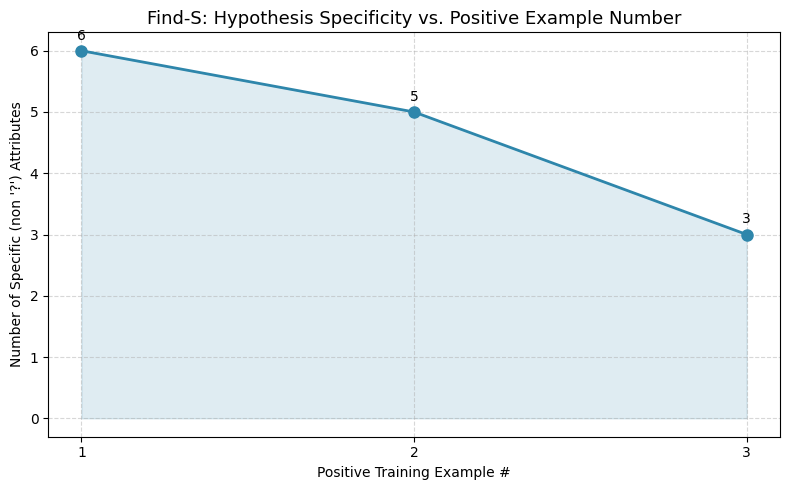


GRAPH
Graph saved to: find_s_graph.png


In [5]:

import csv
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# 1. UPLOAD DATASET
# ============================================================

print("Please upload your house_prices.csv file.")
uploaded = files.upload()

# Get the uploaded filename automatically
DATA_FILE = next(iter(uploaded))

# Positive class label
POSITIVE_LABEL = "Yes"


# ============================================================
# 2. READ CSV FILE
# ============================================================

with open(DATA_FILE, "r", newline="", encoding="utf-8-sig") as f:
    reader = csv.reader(f)

    # Read column names
    header = next(reader)

    # Read remaining rows
    data = [row for row in reader if row]


# ============================================================
# 3. DISPLAY TRAINING DATA
# ============================================================

attributes = header[:-1]

print("=" * 70)
print("TRAINING DATA")
print("=" * 70)

print(", ".join(header))

for row in data:
    print(", ".join(row))


# ============================================================
# 4. FIND-S ALGORITHM
# ============================================================

def find_s(data, positive_label):
    """
    Computes the maximally specific hypothesis consistent
    with the positive training examples.

    Find-S ignores negative examples.

    Returns:
        final hypothesis
        history of hypotheses
    """

    hypothesis = None
    history = []

    for row in data:

        # Separate attributes and target/class label
        *attr_values, label = row

        # Ignore negative examples
        if label.strip().lower() != positive_label.strip().lower():
            continue

        # First positive example
        if hypothesis is None:
            hypothesis = attr_values.copy()

        # Compare subsequent positive examples
        else:
            for i in range(len(hypothesis)):

                if hypothesis[i] != attr_values[i]:
                    hypothesis[i] = "?"

        # Save a copy for displaying/plotting
        history.append(hypothesis.copy())

    return hypothesis, history


# ============================================================
# 5. RUN FIND-S
# ============================================================

final_hypothesis, hypothesis_history = find_s(
    data,
    POSITIVE_LABEL
)


# ============================================================
# 6. DISPLAY FIND-S STEPS
# ============================================================

print("\n" + "=" * 70)
print("FIND-S ALGORITHM — STEP BY STEP")
print("=" * 70)

if not hypothesis_history:
    print("\nNo positive examples were found.")
    print("Check whether POSITIVE_LABEL matches the target column.")
else:

    for step, h in enumerate(hypothesis_history, start=1):
        print(f"After positive example {step}: {h}")


# ============================================================
# 7. DISPLAY FINAL HYPOTHESIS
# ============================================================

print("\n" + "=" * 70)
print("MAXIMALLY SPECIFIC HYPOTHESIS")
print("=" * 70)

print(final_hypothesis)


# ============================================================
# 8. CALCULATE SPECIFICITY SCORE
# ============================================================

def specificity_score(hypothesis):
    """
    Counts how many attributes remain specific
    instead of being generalized to '?'.
    """
    return sum(1 for value in hypothesis if value != "?")


scores = [
    specificity_score(h)
    for h in hypothesis_history
]

iterations = list(
    range(1, len(scores) + 1)
)


# ============================================================
# 9. PLOT GRAPH
# ============================================================

if scores:

    plt.figure(figsize=(8, 5))

    plt.plot(
        iterations,
        scores,
        marker="o",
        linewidth=2,
        markersize=8,
        color="#2E86AB"
    )

    plt.fill_between(
        iterations,
        scores,
        alpha=0.15,
        color="#2E86AB"
    )

    # Display score above each point
    for x, y in zip(iterations, scores):
        plt.annotate(
            str(y),
            (x, y),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center"
        )

    plt.title(
        "Find-S: Hypothesis Specificity vs. Positive Example Number",
        fontsize=13
    )

    plt.xlabel("Positive Training Example #")

    plt.ylabel(
        "Number of Specific (non '?') Attributes"
    )

    plt.xticks(iterations)

    plt.yticks(
        range(0, len(attributes) + 1)
    )

    plt.grid(
        True,
        linestyle="--",
        alpha=0.5
    )

    plt.tight_layout()


    # ========================================================
    # 10. SAVE GRAPH
    # ========================================================

    output_path = "find_s_graph.png"

    plt.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print("\n" + "=" * 70)
    print("GRAPH")
    print("=" * 70)

    print(f"Graph saved to: {output_path}")

else:
    print("\nGraph was not generated because there are no positive examples.")


# ============================================================
# 11. OPTIONAL: DOWNLOAD GRAPH
# ============================================================

# Uncomment the following two lines if you want
# to download the generated graph to your computer.

# files.download("find_s_graph.png")